## FCMB Stock Prediction
We have tried using sector returns to make predictions. We will now try to use just one stock data. FCMB

In [2]:
import pandas as pd

In [4]:
fcmb=pd.read_csv('stock_data/FCMB.csv')

In [5]:
fcmb

,id,symbol,trade_date,open_price,high_price,low_price,close_price,volume,created_at
0,42826,FCMB,2017-01-03,1.10,NaN,NaN,1.10,17981719,2026-04-08T02:41:25.765521+00:00
1,43386,FCMB,2017-01-04,1.11,NaN,NaN,1.11,1346011,2026-04-08T02:42:20.164398+00:00
2,43496,FCMB,2017-01-05,1.12,NaN,NaN,1.12,5449592,2026-04-08T02:42:22.380516+00:00
3,43606,FCMB,2017-01-06,1.17,NaN,NaN,1.17,35871331,2026-04-08T02:42:23.84796+00:00
4,43696,FCMB,2017-01-09,1.28,NaN,NaN,1.28,9482672,2026-04-08T02:42:26.938159+00:00
...,...,...,...,...,...,...,...,...,...
2258,298059,FCMB,2026-07-13,10.10,NaN,NaN,10.10,102235313,2026-07-13T15:10:02.995074+00:00
2259,298497,FCMB,2026-07-14,10.80,NaN,NaN,10.80,16118425,2026-07-14T15:10:03.094441+00:00
2260,298935,FCMB,2026-07-15,10.50,NaN,NaN,10.50,6351340,2026-07-15T15:10:03.078609+00:00
2261,299373,FCMB,2026-07-16,10.50,NaN,NaN,10.50,5634462,2026-07-16T15:10:03.113936+00:00


In [6]:
fcmb=fcmb.drop(columns=['high_price','low_price'])

In [7]:
fcmb.rename(columns={'trade_date':'date'},inplace=True)

In [8]:
fcmb['date']=pd.to_datetime(fcmb['date'])
fcmb.info()

<class 'pandas.DataFrame'>
RangeIndex: 2263 entries, 0 to 2262
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           2263 non-null   int64         
 1   symbol       2263 non-null   str           
 2   date         2263 non-null   datetime64[us]
 3   open_price   2262 non-null   float64       
 4   close_price  2263 non-null   float64       
 5   volume       2263 non-null   int64         
 6   created_at   2263 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(2), str(2)
memory usage: 123.9 KB


lets try to include seasonality.

In [9]:
fcmb['month']=fcmb['date'].dt.month
fcmb['quarter']=fcmb['date'].dt.quarter
fcmb['year']=fcmb['date'].dt.year

In [10]:
fcmb

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42826,FCMB,2017-01-03,1.10,1.10,17981719,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43386,FCMB,2017-01-04,1.11,1.11,1346011,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43496,FCMB,2017-01-05,1.12,1.12,5449592,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43606,FCMB,2017-01-06,1.17,1.17,35871331,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43696,FCMB,2017-01-09,1.28,1.28,9482672,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298059,FCMB,2026-07-13,10.10,10.10,102235313,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298497,FCMB,2026-07-14,10.80,10.80,16118425,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298935,FCMB,2026-07-15,10.50,10.50,6351340,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299373,FCMB,2026-07-16,10.50,10.50,5634462,2026-07-16T15:10:03.113936+00:00,7,3,2026


In [11]:
fcmb.close_price.describe()

count    2263.000000
mean        4.605038
std         3.497623
min         0.930000
25%         1.840000
50%         3.060000
75%         7.600000
max        13.900000
Name: close_price, dtype: float64

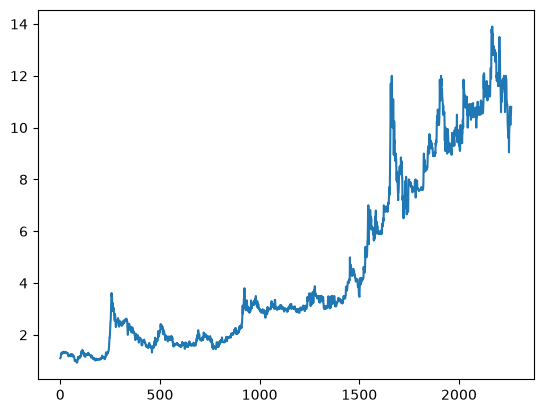

In [12]:
import matplotlib.pyplot as plt

plt.plot(fcmb['close_price'])
plt.show()

In [13]:
fcmb['returns']=fcmb['close_price'].pct_change()*100

In [14]:
fcmb

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,42826,FCMB,2017-01-03,1.10,1.10,17981719,2026-04-08T02:41:25.765521+00:00,1,1,2017,NaN
1,43386,FCMB,2017-01-04,1.11,1.11,1346011,2026-04-08T02:42:20.164398+00:00,1,1,2017,0.909091
2,43496,FCMB,2017-01-05,1.12,1.12,5449592,2026-04-08T02:42:22.380516+00:00,1,1,2017,0.900901
3,43606,FCMB,2017-01-06,1.17,1.17,35871331,2026-04-08T02:42:23.84796+00:00,1,1,2017,4.464286
4,43696,FCMB,2017-01-09,1.28,1.28,9482672,2026-04-08T02:42:26.938159+00:00,1,1,2017,9.401709
...,...,...,...,...,...,...,...,...,...,...,...
2258,298059,FCMB,2026-07-13,10.10,10.10,102235313,2026-07-13T15:10:02.995074+00:00,7,3,2026,-6.481481
2259,298497,FCMB,2026-07-14,10.80,10.80,16118425,2026-07-14T15:10:03.094441+00:00,7,3,2026,6.930693
2260,298935,FCMB,2026-07-15,10.50,10.50,6351340,2026-07-15T15:10:03.078609+00:00,7,3,2026,-2.777778
2261,299373,FCMB,2026-07-16,10.50,10.50,5634462,2026-07-16T15:10:03.113936+00:00,7,3,2026,0.000000


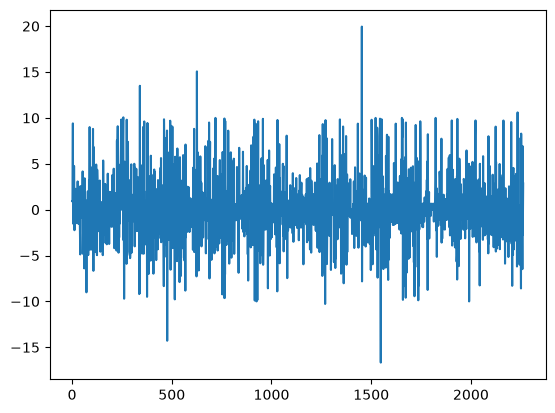

In [15]:
plt.plot(fcmb['returns'])
plt.show()

In [16]:
fcmb2=fcmb.dropna()

## AUTOCORRELATION

In [18]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(fcmb2['returns'])
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-36.45029984903722), 0.0, 1, 2259, {'1%': np.float64(-3.433248072725654), '5%': np.float64(-2.8628202931061955), '10%': np.float64(-2.567451559747925)}, np.float64(11620.172519048374))
stationary


It is stationary.

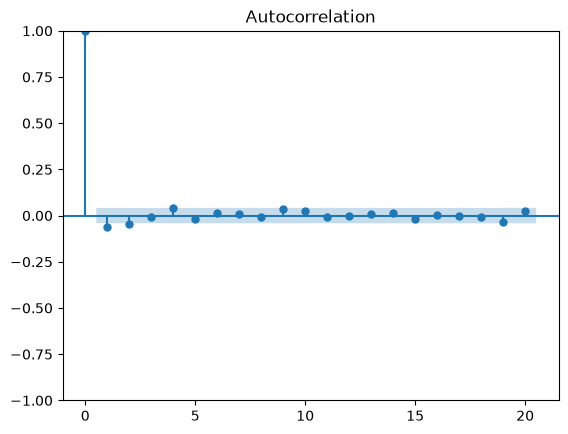

In [22]:
# Autocorrelation of the differenced data
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
plot_acf(fcmb2.returns, lags=20) ## acf is short for autocorrelation function
plt.show()

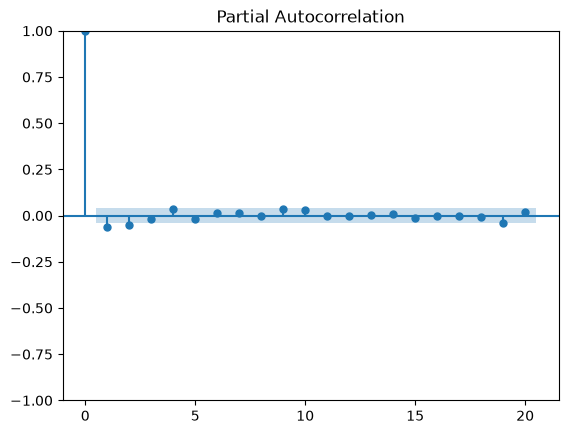

In [20]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(fcmb2.returns, lags = 20)
plt.show()

In [27]:

from sklearn.metrics import r2_score
from statsmodels.regression.linear_model import yule_walker

# Apply a grid search to find the order that gives the best R2 score on the test data

def evaluate(order):
    train = list(fcmb2['returns'])[:-10]
    test = list(fcmb2['returns'])[-10:]

    coefficients, sigma = yule_walker(train, order = order)

    # Make a list of differenced values
    val_list = list(train)

    # Reverse the list to corresponds with the order of coefs
    val_list.reverse()

    # Define the number of years to predict
    n_steps = 10

    # For each day to predict
    for i in range(n_steps):
        # Compute the new value
        new_val = 0
        for j in range(len(coefficients)):
            new_val += coefficients[j] * val_list[j]

        # Insert the new value at the beginning of the list
        val_list.insert(0, new_val)

    # Redo the reverse to have the order of time
    val_list.reverse()
    new_val_list= val_list

    # Plot the newly obtained list
    test_validation = pd.DataFrame({
        'original': list(fcmb2['returns']),
        'test_pred': new_val_list 
    })
    
    return r2_score(test_validation.iloc[-10:, 0], test_validation.iloc[-10:, 1])



In [28]:
# For each order between 1 and 30, fit and evaluate the model
orders = []
r2scores = []
for order in range(1, 31):
    orders.append(order)
    r2scores.append(evaluate(order))

# Create a results data frame
results =pd.DataFrame({'orders': orders,'scores': r2scores})

# Show the order with best R2 score
results[results['scores'] == results.max()['scores']]

,orders,scores
25,26,-0.090391


In [30]:
results

,orders,scores
0,1,-0.102897
1,2,-0.120196
2,3,-0.111386
3,4,-0.116213
4,5,-0.116718
5,6,-0.133011
6,7,-0.120252
7,8,-0.117807
8,9,-0.173967
9,10,-0.139639


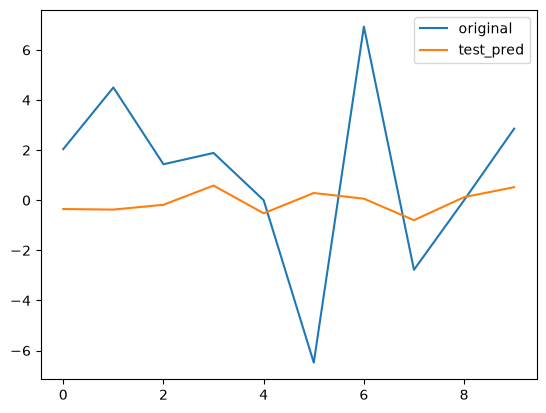

In [33]:
train = list(fcmb2['returns'])[:-10]
test = list(fcmb2['returns'])[-10:]

coefficients, sigma = yule_walker(train, order = 26)

# Make a list of differenced values
val_list = list(train)

# Reverse the list to corresponds with the order of coefs
val_list.reverse()

# Define the number of years to predict
n_steps = 10

# For each day to predict
for i in range(n_steps):
    # Compute the new value
    new_val = 0
    for j in range(len(coefficients)):
        new_val += coefficients[j] * val_list[j]

    # Insert the new value at the beginning of the list
    val_list.insert(0, new_val)

# Redo the reverse to have the order of time
val_list.reverse()
new_val_list= val_list

# Plot the newly obtained list
test_validation = pd.DataFrame({
    'original': list(fcmb2['returns']),
    'test_pred': new_val_list 
})

r2_score(test_validation.iloc[-10:, 0], test_validation.iloc[-10:, 1])

plt.plot(list(fcmb2['returns'])[-10:])
plt.plot(new_val_list[-10:])
plt.legend(test_validation.columns)
plt.show()

AR performance is not good. Lets head straight to ARIMA.

## ARIMA

In this case we will use the close_price.

In [34]:
fcmb2

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
1,43386,FCMB,2017-01-04,1.11,1.11,1346011,2026-04-08T02:42:20.164398+00:00,1,1,2017,0.909091
2,43496,FCMB,2017-01-05,1.12,1.12,5449592,2026-04-08T02:42:22.380516+00:00,1,1,2017,0.900901
3,43606,FCMB,2017-01-06,1.17,1.17,35871331,2026-04-08T02:42:23.84796+00:00,1,1,2017,4.464286
4,43696,FCMB,2017-01-09,1.28,1.28,9482672,2026-04-08T02:42:26.938159+00:00,1,1,2017,9.401709
5,43806,FCMB,2017-01-10,1.30,1.30,37135120,2026-04-08T02:42:29.227202+00:00,1,1,2017,1.562500
...,...,...,...,...,...,...,...,...,...,...,...
2258,298059,FCMB,2026-07-13,10.10,10.10,102235313,2026-07-13T15:10:02.995074+00:00,7,3,2026,-6.481481
2259,298497,FCMB,2026-07-14,10.80,10.80,16118425,2026-07-14T15:10:03.094441+00:00,7,3,2026,6.930693
2260,298935,FCMB,2026-07-15,10.50,10.50,6351340,2026-07-15T15:10:03.078609+00:00,7,3,2026,-2.777778
2261,299373,FCMB,2026-07-16,10.50,10.50,5634462,2026-07-16T15:10:03.113936+00:00,7,3,2026,0.000000


In [35]:
# Applying an ADF test to the differenced data
from statsmodels.tsa.stattools import adfuller

result = adfuller(fcmb2['returns'])

pvalue = result[1]

if pvalue < 0.05:
    print('stationary', result[1])
else:
    print('not stationary',result[1])

stationary 0.0


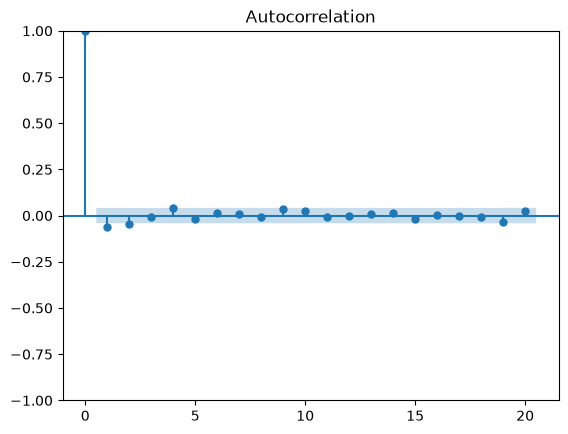

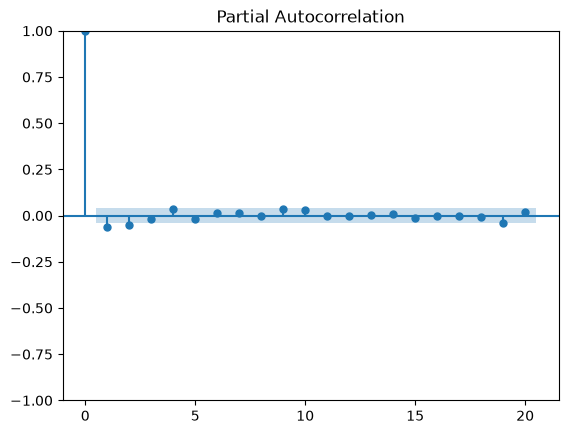

In [36]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(fcmb2['returns'], lags=20)
plot_pacf(fcmb2['returns'], lags=20)
plt.show()

In [38]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings('ignore')

data_array = fcmb2[['close_price']].values

avg_errors = []

for p in range(6):
    for q in range(6):
        for i in range(3):
            errors = []
            tscv = TimeSeriesSplit(test_size=10)

            for train_index, test_index in tscv.split(data_array):
                X_train = data_array[train_index]
                X_test = data_array[test_index]
                X_test_orig = X_test.copy()
                fcst = []

                for step in range(10):
                    try:
                        mod = ARIMA(X_train, order=(p, i, q))
                        res = mod.fit()

                        # Convert forecast from array to scalar
                        forecast = res.forecast(steps=1)[0]
                        fcst.append(forecast)

                    except Exception as e:
                        print(f"Error for p={p}, i={i}, q={q}, step={step}: {e}")

                        # Use a scalar here as well
                        fcst.append(np.nan)

                    # Add actual observation to training data
                    X_train = np.concatenate(
                        (X_train, X_test[0:1, :])
                    )

                    # Remove first test observation
                    X_test = X_test[1:]

                # Convert actual values to 1D
                y_true = X_test_orig.ravel()

                # Convert forecasts to 1D
                y_pred = np.array(fcst)

                # Don't calculate R² if a model failed
                if np.isnan(y_pred).any():
                    errors.append(np.nan)
                else:
                    errors.append(r2_score(y_true, y_pred))

            pq_result = [p, i, q, np.nanmean(errors)]
            print(pq_result)
            avg_errors.append(pq_result)

[0, 0, 0, np.float64(-316.6134728775325)]
[0, 1, 0, np.float64(-0.08036767238274697)]
[0, 2, 0, np.float64(-1.5879439116168033)]
[0, 0, 1, np.float64(-84.40213091010204)]
[0, 1, 1, np.float64(-0.06353893010123635)]
[0, 2, 1, np.float64(-0.07933612231412376)]
[0, 0, 2, np.float64(-32.02286604787969)]
[0, 1, 2, np.float64(-0.06161365817597366)]
[0, 2, 2, np.float64(-0.06207206682662232)]
[0, 0, 3, np.float64(-13.668257523985147)]
[0, 1, 3, np.float64(-0.06560942495503488)]
[0, 2, 3, np.float64(-0.06005058997441903)]
[0, 0, 4, np.float64(-11.047654564774021)]
[0, 1, 4, np.float64(-0.057581426016619995)]
[0, 2, 4, np.float64(-0.0645197041001172)]
[0, 0, 5, np.float64(-5.971790476040569)]
[0, 1, 5, np.float64(-0.05965787905976374)]
[0, 2, 5, np.float64(-0.055991592202048523)]
[1, 0, 0, np.float64(-0.0832341494982433)]
[1, 1, 0, np.float64(-0.06524190355240655)]
[1, 2, 0, np.float64(-0.8144670125834557)]
[1, 0, 1, np.float64(-0.06652509393997652)]
[1, 1, 1, np.float64(-0.0620813323489011)]
[

KeyboardInterrupt: 

We interrupted it because it was taking too long without any signs of improvement

### We will move to SARIMA

buts lets go back a bit to linear regression

In [39]:
fcmb2

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
1,43386,FCMB,2017-01-04,1.11,1.11,1346011,2026-04-08T02:42:20.164398+00:00,1,1,2017,0.909091
2,43496,FCMB,2017-01-05,1.12,1.12,5449592,2026-04-08T02:42:22.380516+00:00,1,1,2017,0.900901
3,43606,FCMB,2017-01-06,1.17,1.17,35871331,2026-04-08T02:42:23.84796+00:00,1,1,2017,4.464286
4,43696,FCMB,2017-01-09,1.28,1.28,9482672,2026-04-08T02:42:26.938159+00:00,1,1,2017,9.401709
5,43806,FCMB,2017-01-10,1.30,1.30,37135120,2026-04-08T02:42:29.227202+00:00,1,1,2017,1.562500
...,...,...,...,...,...,...,...,...,...,...,...
2258,298059,FCMB,2026-07-13,10.10,10.10,102235313,2026-07-13T15:10:02.995074+00:00,7,3,2026,-6.481481
2259,298497,FCMB,2026-07-14,10.80,10.80,16118425,2026-07-14T15:10:03.094441+00:00,7,3,2026,6.930693
2260,298935,FCMB,2026-07-15,10.50,10.50,6351340,2026-07-15T15:10:03.078609+00:00,7,3,2026,-2.777778
2261,299373,FCMB,2026-07-16,10.50,10.50,5634462,2026-07-16T15:10:03.113936+00:00,7,3,2026,0.000000


train_accuracy:  0.7096610614607173 ,  test accuracy:  -7.58176909158909


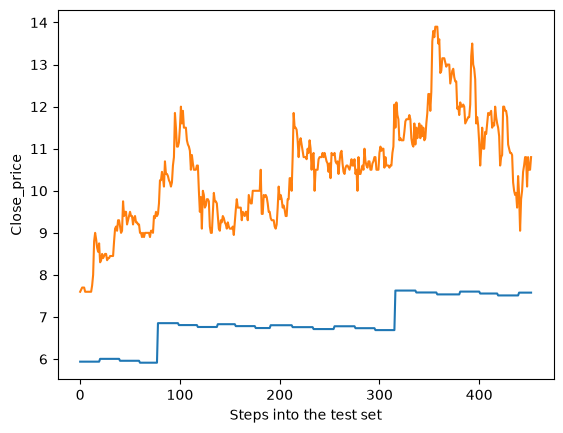

In [40]:
# Create X and y objects
X = fcmb2[['year', 'month', 'quarter']]
y = fcmb2['close_price']
# Create Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, 
random_state=12345,shuffle=False)
# Fit model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

my_lm = LinearRegression()
my_lm.fit(X = X_train, y = y_train)

train_fcst = my_lm.predict(X_train)
test_fcst = my_lm.predict(X_test)

train_r2 = r2_score(y_train, train_fcst)
test_r2 = r2_score(y_test, test_fcst)

print('train_accuracy: ',train_r2,',  test accuracy: ', test_r2)
# Plot result
plt.plot(list(test_fcst))
plt.plot(list(y_test))
plt.xlabel('Steps into the test set')
plt.ylabel('Close_price')
plt.show()

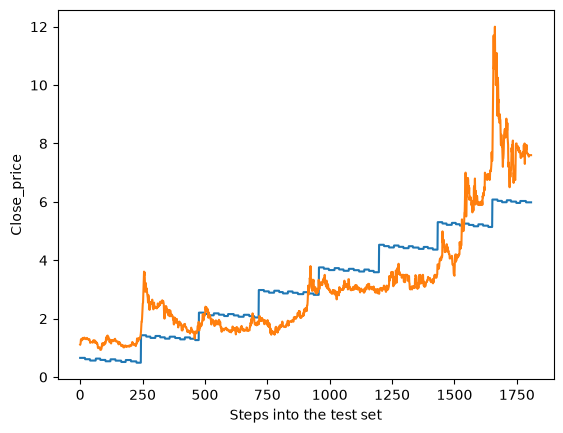

In [41]:

plt.plot(list(train_fcst))
plt.plot(list(y_train))
plt.xlabel('Steps into the test set')
plt.ylabel('Close_price')
plt.show()

let us apply lag to lag 20

In [42]:
fcmb_lag=fcmb2.copy()

In [43]:
fcmb_lag['close_price_L1']=fcmb_lag['close_price'].shift(1)
fcmb_lag['close_price_L2']=fcmb_lag['close_price'].shift(2)
fcmb_lag['close_price_L5']=fcmb_lag['close_price'].shift(5)
fcmb_lag['close_price_L10']=fcmb_lag['close_price'].shift(10)
fcmb_lag['close_price_L15']=fcmb_lag['close_price'].shift(15)
fcmb_lag['close_price_L20']=fcmb_lag['close_price'].shift(20)
fcmb_lag['close_price_L30']=fcmb_lag['close_price'].shift(30)
fcmb_lag['close_price_L45']=fcmb_lag['close_price'].shift(45)
fcmb_lag['close_price_L60']=fcmb_lag['close_price'].shift(60)
fcmb_lag['close_price_L90']=fcmb_lag['close_price'].shift(90)

fcmb_lag=fcmb_lag.dropna()
fcmb_lag.shape


(2171, 21)

In [45]:
fcmb_lag.columns

Index(['id', 'symbol', 'date', 'open_price', 'close_price', 'volume',
       'created_at', 'month', 'quarter', 'year', 'returns', 'close_price_L1',
       'close_price_L2', 'close_price_L5', 'close_price_L10',
       'close_price_L15', 'close_price_L20', 'close_price_L30',
       'close_price_L45', 'close_price_L60', 'close_price_L90'],
      dtype='str')

train_accuracy:  0.9952837696873317 ,  test accuracy:  0.9329020080606281


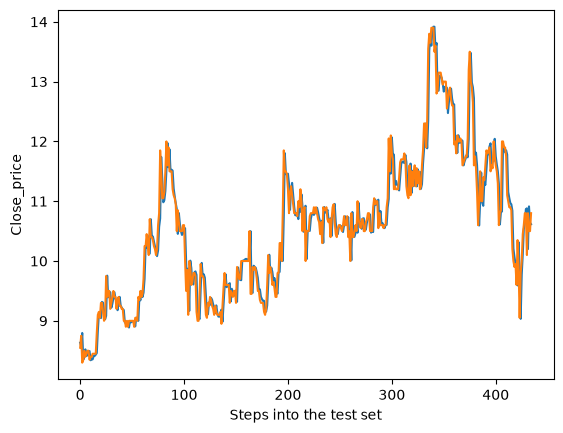

In [54]:
# Create X and y objects
X = fcmb_lag[['year', 'month', 'quarter','close_price_L1',
       'close_price_L2', 'close_price_L5', 'close_price_L10',
       'close_price_L15', 'close_price_L20','close_price_L30', 'close_price_L45','close_price_L60', 'close_price_L90'
    ]]

y = fcmb_lag['close_price']

# Create Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, 
random_state=12345,shuffle=False)

# Fit model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

my_lm = LinearRegression()
my_lm.fit(X = X_train, y = y_train)

train_fcst = my_lm.predict(X_train)
test_fcst = my_lm.predict(X_test)

train_r2 = r2_score(y_train, train_fcst)
test_r2 = r2_score(y_test, test_fcst)

print('train_accuracy: ',train_r2,',  test accuracy: ', test_r2)
# Plot result
plt.plot(list(test_fcst))
plt.plot(list(y_test))
plt.xlabel('Steps into the test set')
plt.ylabel('Close_price')
plt.show()

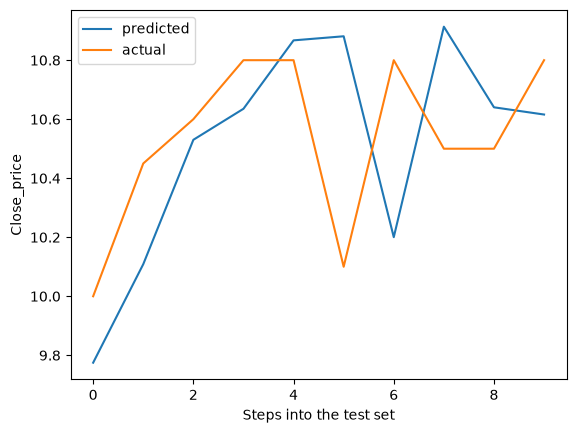

In [55]:
# Plot result
plt.plot(list(test_fcst)[-10:])
plt.plot(list(y_test)[-10:])
plt.xlabel('Steps into the test set')
plt.ylabel('Close_price')
plt.legend(['predicted','actual'])
plt.show()

Lagging basically uses previous to predict next. it is almost stochastic.